BLOK 1: Persiapan & Download Dataset
(Tugas: Menyiapkan library dan mengambil data)

In [ ]:
# --- BLOK 1: SETUP & DOWNLOAD ---
import os
import zipfile
import shutil

In [ ]:
# 1. Install Library Khusus
print("Menginstall library LIME...")
!pip install lime

Menginstall library LIME...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8170f1897c24d3ebd02d171ded35bdac971825a11cfa419951e7b644f714d819
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
# 2. Upload kaggle.json
from google.colab import files
if not os.path.exists('kaggle.json'):
    print("\n=== SILAKAN UPLOAD FILE kaggle.json ANDA ===")
    files.upload()


=== SILAKAN UPLOAD FILE kaggle.json ANDA ===


Saving kaggle.json to kaggle.json


In [ ]:
# 3. Konfigurasi Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# 4. Download Dataset
if not os.path.exists("dataset_raw"):
    print("\nSedang mendownload dataset...")
    !kaggle datasets download -d smaranjitghose/corn-or-maize-leaf-disease-dataset
    print("Mengekstrak data...")
    with zipfile.ZipFile("corn-or-maize-leaf-disease-dataset.zip", 'r') as zip_ref:
        zip_ref.extractall("dataset_raw")

print("\n✅ Persiapan Selesai. Lanjut ke Blok 2.")


Sedang mendownload dataset...
Dataset URL: https://www.kaggle.com/datasets/smaranjitghose/corn-or-maize-leaf-disease-dataset
License(s): copyright-authors
 96% 155M/161M [00:00<00:00, 1.61GB/s]
100% 161M/161M [00:00<00:00, 1.60GB/s]
Mengekstrak data...

✅ Persiapan Selesai. Lanjut ke Blok 2.


BLOK 2: Data Generator & Preprocessing CLAHE
(Tugas: Menyiapkan 'pipa' data otomatis dengan CLAHE agar RAM aman)

In [ ]:
# --- BLOK 2: GENERATOR & CLAHE ---
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Definisi Fungsi CLAHE
def apply_clahe_preprocessing(img):
    # img masuk sebagai float/int, paksa ke uint8 untuk OpenCV
    img = img.astype(np.uint8)

    # Ubah ke LAB & Terapkan CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Clip Limit 2.0, Grid 8x8 (Standar Bagus)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)

    lab_new = cv2.merge((l2, a, b))
    img_clahe = cv2.cvtColor(lab_new, cv2.COLOR_LAB2RGB)

    # Normalisasi ke 0-1 (Format yang disukai Neural Network)
    return img_clahe.astype(np.float32) / 255.0

In [ ]:
# 2. Setup Generator
IMG_SIZE = 224
BATCH_SIZE = 32
DATA_DIR = "dataset_raw/data"

print("Menyiapkan Data Generator...")

# Kita set validation_split 20%
datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe_preprocessing, # CLAHE dipasang di sini
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False # Jangan shuffle biar urutan evaluasi benar
)

# Simpan nama kelas untuk nanti
CATEGORIES = list(train_generator.class_indices.keys())
print(f"Kelas terdeteksi: {CATEGORIES}")

Menyiapkan Data Generator...
Found 3352 images belonging to 4 classes.
Found 836 images belonging to 4 classes.
Kelas terdeteksi: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


Blok 2.5 (Visualisasi Preprocessing)

In [ ]:
# --- BLOK 2.5: CEK VISUALISASI CLAHE (WAJIB UNTUK GAMBAR 1 ARTIKEL) ---
import matplotlib.pyplot as plt
import os

In [ ]:
# 1. Ambil 1 sampel gambar secara acak dari folder 'Blight'
# (Pastikan Blok 1 & 2 sudah dijalankan sebelumnya)
sample_folder = os.path.join(DATA_DIR, 'Blight')
sample_files = os.listdir(sample_folder)
sample_path = os.path.join(sample_folder, sample_files[0]) # Ambil file pertama

In [ ]:
# 2. Baca Gambar Asli
img_original = cv2.imread(sample_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

In [ ]:
# 3. Terapkan Fungsi CLAHE yang sudah kita buat di Blok 2
# Kita perlu copy agar gambar asli tidak berubah
img_clahe = apply_clahe_preprocessing(img_original.copy())

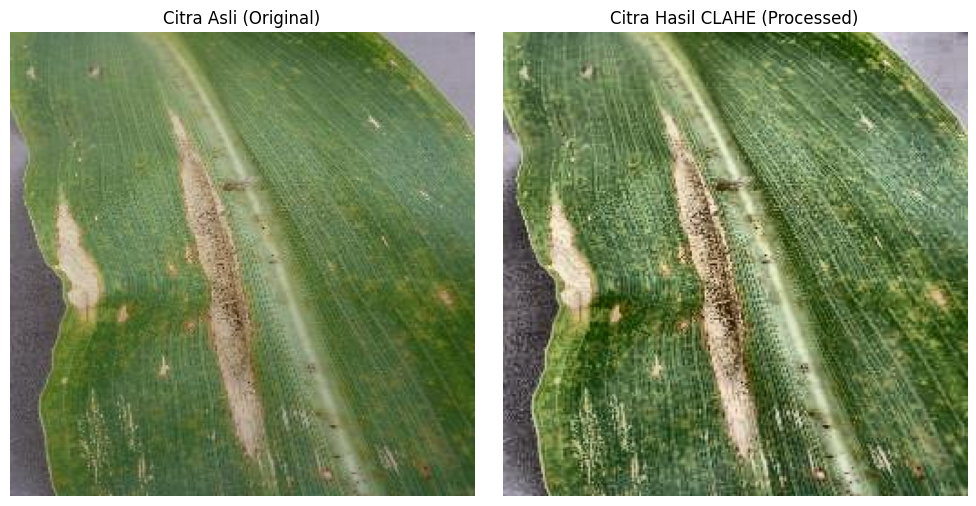

In [ ]:
# 4. Tampilkan Perbandingannya
plt.figure(figsize=(10, 5))

# Plot Gambar Asli
plt.subplot(1, 2, 1)
plt.imshow(img_original)
plt.title("Citra Asli (Original)")
plt.axis('off')

# Plot Gambar Hasil CLAHE
plt.subplot(1, 2, 2)
plt.imshow(img_clahe)
plt.title("Citra Hasil CLAHE (Processed)")
plt.axis('off')

plt.tight_layout()
plt.show()

BLOK 3: Training Awal (Transfer Learning)
(Tugas: Melatih model dasar EfficientNet-B0)

In [ ]:
# --- BLOK 3: MODELING (WARM UP) ---
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers, callbacks

In [ ]:
# 1. Load EfficientNet (Tanpa Kepala)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False # Bekukan dulu (Freeze)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 2. Tambah Kepala Baru (Classification Head)
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax') # 4 Kelas
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# 3. Training Tahap 1
print("\nMulai Training Tahap 1 (Warm Up)...")
history = model.fit(
    train_generator,
    epochs=10,  # Cukup 10 epoch dulu
    validation_data=val_generator
)


Mulai Training Tahap 1 (Warm Up)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 78s 483ms/step - accuracy: 0.3184 - loss: 1.5727 - val_accuracy: 0.2739 - val_loss: 1.3717
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - accuracy: 0.3443 - loss: 1.4163 - val_accuracy: 0.3122 - val_loss: 1.3353
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 18s 170ms/step - accuracy: 0.3748 - loss: 1.3494 - val_accuracy: 0.4342 - val_loss: 1.3408
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - accuracy: 0.3822 - loss: 1.3043 - val_accuracy: 0.4450 - val_loss: 1.2972
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 172ms/step - accuracy: 0.3896 - loss: 1.3185 - val_accuracy: 0.4474 - val_loss: 1.2564
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 18s 172ms/step - accuracy: 0.4384 - loss: 1.2464 - val_accuracy: 0.4557 - val_loss: 1.1909
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 18s 171ms/step - accuracy: 0.4283 - loss: 1.2383 - val_accuracy: 0.5108 - val_loss: 1.1575
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 18s 172ms/step - accuracy: 0.4325 - loss: 1

BLOK 4: Fine Tuning (Kunci Akurasi Tinggi)
(Tugas: Membuka 'otak' model dan melatih ulang pelan-pelan)

In [ ]:
# --- BLOK 4: FINE TUNING (BOOST PERFORMA) ---

# 1. Unfreeze (Cairkan) semua layer
base_model.trainable = True

In [ ]:
# 2. Compile Ulang dengan Learning Rate Kecil
model.compile(optimizer=optimizers.Adam(learning_rate=1e-4), # LR Kecil biar bobot tidak rusak
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 3. Callbacks Pengaman
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print("\nMulai Training Tahap 2 (Fine Tuning)... Harap bersabar.")
history_fine = model.fit(
    train_generator,
    epochs=15, # Tambah 15 epoch lagi
    validation_data=val_generator,
    callbacks=[early_stopping]
)

print("✅ Training Selesai! Model siap dievaluasi.")


Mulai Training Tahap 2 (Fine Tuning)... Harap bersabar.
Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 182s 889ms/step - accuracy: 0.6901 - loss: 0.7776 - val_accuracy: 0.2775 - val_loss: 3.0529
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 190ms/step - accuracy: 0.9117 - loss: 0.2640 - val_accuracy: 0.4641 - val_loss: 2.5110
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 204ms/step - accuracy: 0.9516 - loss: 0.1379 - val_accuracy: 0.3624 - val_loss: 2.6566
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - accuracy: 0.9667 - loss: 0.1001 - val_accuracy: 0.4665 - val_loss: 1.9719
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step - accuracy: 0.9683 - loss: 0.0858 - val_accuracy: 0.6208 - val_loss: 1.3670
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - accuracy: 0.9857 - loss: 0.0449 - val_accuracy: 0.6507 - val_loss: 1.5810
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - accuracy: 0.9840 - loss: 0.0369 - val_accuracy: 0.6878 - val_loss: 1.3889
Epoch 8/15
105/105 ━━━━━━

BLOK 5: Evaluasi Kuantitatif (Tabel & Confusion Matrix)
(Tugas: Menghasilkan data angka dan grafik kotak biru untuk Laporan)

In [ ]:
# --- BLOK 5: EVALUASI KUANTITATIF ---
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

In [ ]:
# 1. Prediksi
print("Sedang mengevaluasi model...")
val_generator.reset()
Y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

Sedang mengevaluasi model...
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 395ms/step


In [ ]:
# 2. Classification Report (Untuk Tabel)
report = classification_report(y_true, y_pred_classes, target_names=CATEGORIES, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print("\n=== HASIL UNTUK TABEL ARTIKEL ===")
print(df_report)


=== HASIL UNTUK TABEL ARTIKEL ===
                precision    recall  f1-score     support
Blight           0.889908  0.847162  0.868009  229.000000
Common_Rust      0.931900  0.996169  0.962963  261.000000
Gray_Leaf_Spot   0.825243  0.745614  0.783410  114.000000
Healthy          0.974576  0.991379  0.982906  232.000000
accuracy         0.919856  0.919856  0.919856    0.919856
macro avg        0.905407  0.895081  0.899322  836.000000
weighted avg     0.917696  0.919856  0.918003  836.000000


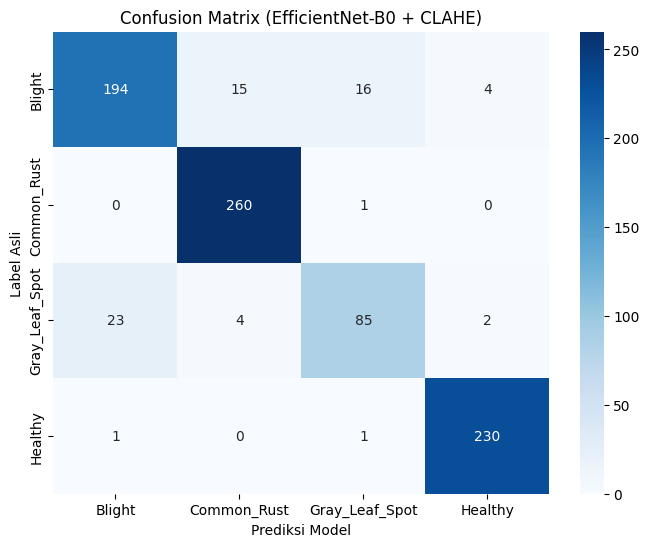

In [ ]:
# 3. Confusion Matrix (Untuk Gambar)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('Confusion Matrix (EfficientNet-B0 + CLAHE)')
plt.ylabel('Label Asli'); plt.xlabel('Prediksi Model')
plt.show()

BLOK 6: Explainable AI / LIME (Qualitative)
(Tugas: Menghasilkan gambar visualisasi "Otak Model" yang benar, bukan gambar putih)

In [ ]:
# --- BLOK 6: VISUALISASI LIME (CORRECTED) ---
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [ ]:
# 1. Fungsi 'Jembatan' (Raw -> CLAHE -> Model)
def predict_fn(images):
    processed_imgs = []
    for img in images:
        if img.max() > 1: img = img.astype(np.float32)
        # Terapkan CLAHE yang sama persis dengan saat training
        processed_img = apply_clahe_preprocessing(img)
        processed_imgs.append(processed_img)
    return model.predict(np.array(processed_imgs))

In [ ]:
# 2. Ambil Sampel (Misal: Blight)
# Ganti 'Blight' dengan 'Gray_Leaf_Spot' atau 'Common_Rust' jika mau coba yang lain
target_class = 'Blight'
sample_path = os.path.join(DATA_DIR, target_class, os.listdir(os.path.join(DATA_DIR, target_class))[0])

img_raw = cv2.imread(sample_path)
img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
img_raw = cv2.resize(img_raw, (IMG_SIZE, IMG_SIZE))

In [ ]:
# 3. Jalankan LIME
print(f"Menganalisis gambar {target_class} dengan LIME...")
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    img_raw.astype('double'),
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=2000 # 2000 sampel cukup akurat
)

Menganalisis gambar Blight dengan LIME...


  0%|          | 0/2000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━

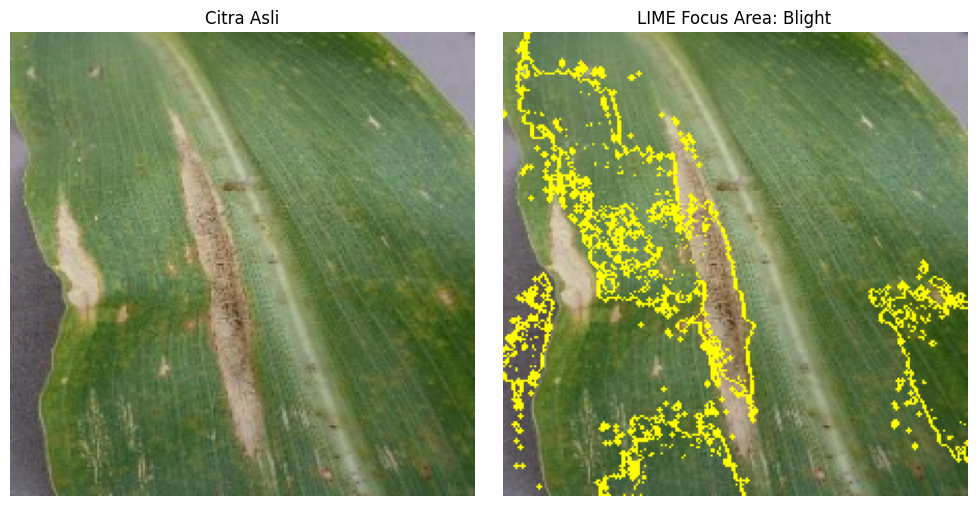

In [ ]:
# 4. Tampilkan (Tanpa Rumus Normalisasi yang Bikin Putih)
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)
img_display = temp.astype(np.uint8) # Kunci biar warnanya benar

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img_raw); plt.title("Citra Asli")
plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(mark_boundaries(img_display, mask));
plt.title(f"LIME Focus Area: {CATEGORIES[explanation.top_labels[0]]}")
plt.axis('off')
plt.tight_layout(); plt.show()